# gpt4 for entailment



In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [2]:
# export to eval file
def get_vals(x):
    return x['mean'], x['mean']-x['bootstrap']['std_err'], x['mean']+x['bootstrap']['std_err']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

get_cfg = lambda dictionary: {k: v['value'] for k, v in dictionary.items() if isinstance(v, dict) and k != '_wandb'}
def get_diff(xk, yk):

    x, y = all_configs[xk], all_configs[yk]
    print(20*' ' + f'{runs[xk]:<20} {runs[yk]}')
    diffs = set(get_cfg(x).items()) ^ set(get_cfg(y).items())
    diffs = set([k for k, v in diffs])
    for k in diffs:
        print(f'{k:<20} {get_cfg(x).get(k, "missing"):<20} {get_cfg(y).get(k, "missing")}')
    print(80 * '-')


In [3]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

Questions

* Which (strict/lax, deberta/gpt/llama) gives best performance on average?
* Make a table that is [strictness, entailment] with auroc!

In [4]:
# The new runs are doing strict entailment _and_ condition on question,
runs = {
#     'sy2g4uyv': '70b-trivia-qa',
#     'ispvyuub': '70b-trivia-no-context',
#     # NOTE: 70-bSQUAD RUNS ONLY HAVE 5 GENERATIONS !!
#     '3dh1kja3': '70b-squad', # n2bhdjad
#     'jky7j51k': '70b-squad-AO', # answerable only 'ttd2db7b''
#     'zodwzypf': '70b-squad-AO-NC', # answerable only, no-context 'ttd2db7b''
# # 
#     '4qrza8sl': '7b-trivia-qa',
#     'gk0phirh': '7b-trivia-no-context',
#     '7nlpwfzq': '7b-squad', # n2bhdjad
#     'bd90qu2n': '7b-squad-AO', # answerable only 'ttd2db7b''
#     'cizk4p88': '7b-squad-AO-NC', # answerable only, no-context 'ttd2db7b''
# 
    # 'jjggmw43': '7b-squad', # AO/NC
    # '0hyjzs16': '7b-trivia_qa',  # NC
    # 'z4r9jeiz': '7b-bioasq',
    'ooslwgb9': '70b-squad-lax-deberta',
    'iuh4ny1v': '70b-squad-strict-deberta',
    'fbtvpw1y': '70b-squad-lax-llama',
    'h5vd2k6a': '70b-squad-strict-llama',
    'rzj7w9ei': '70b-squad-lax-gpt4',
    'e0z3555u': '70b-squad-strict-gpt4',
    # 
    'au7s3uxg': '70b-trivia_qa-lax-deberta',
    'a0x5b6bc': '70b-trivia_qa-strict-deberta',
    '0arsdrk9': '70b-trivia_qa-lax-llama',
    '4g1egsbm': '70b-trivia_qa-strict-llama',
    '91auvvo2': '70b-trivia_qa-lax-gpt4',
    'oxk8fe6o': '70b-trivia_qa-strict-gpt4',
    #
    'e5ptgcwr': '70b-bioasq-lax-deberta',
    '4cceyw6c': '70b-bioasq-strict-deberta',
    'lu4uikdt': '70b-bioasq-lax-llama',
    'o7xsfdju': '70b-bioasq-strict-llama',
    'dn62rrv2': '70b-bioasq-lax-gpt4',
    'ustnzl3g': '70b-bioasq-strict-gpt4',
}



all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


In [5]:
# get_diff('au7s3uxg', '4g1egsbm')

Can we improve accuracy by instead voting the answer from the (high-temperature) clusters?

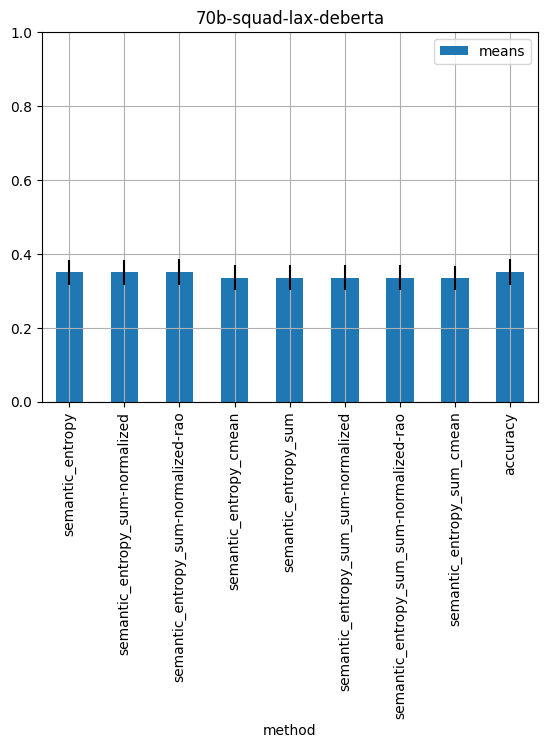

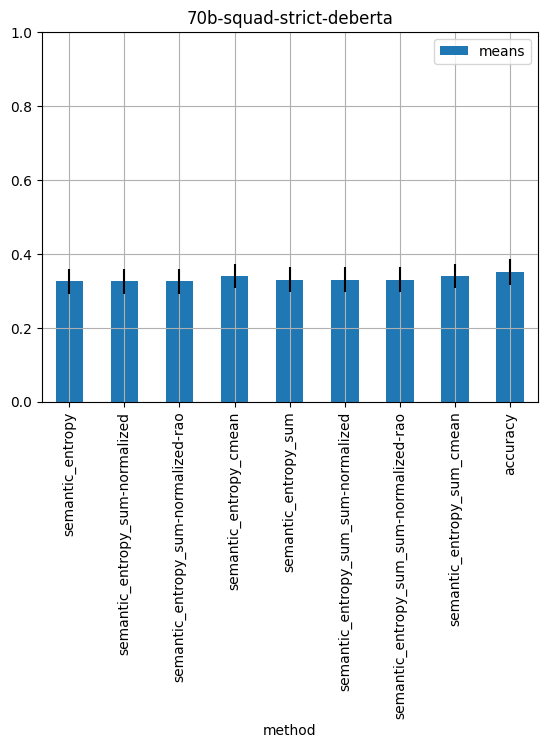

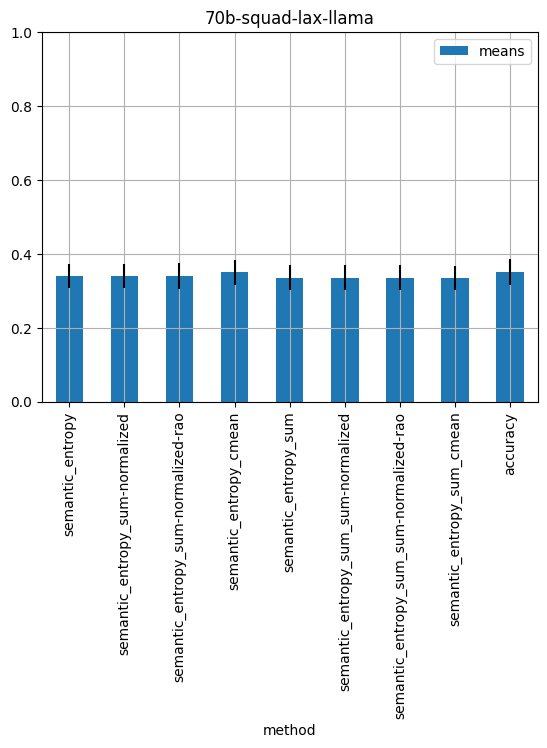

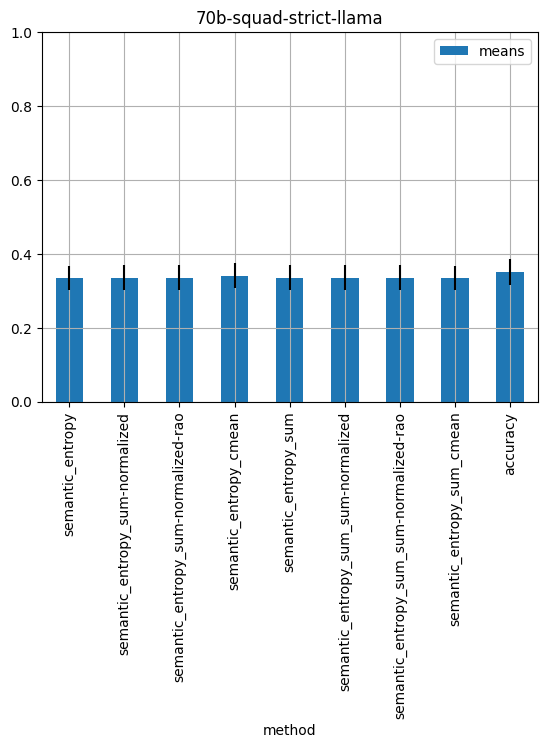

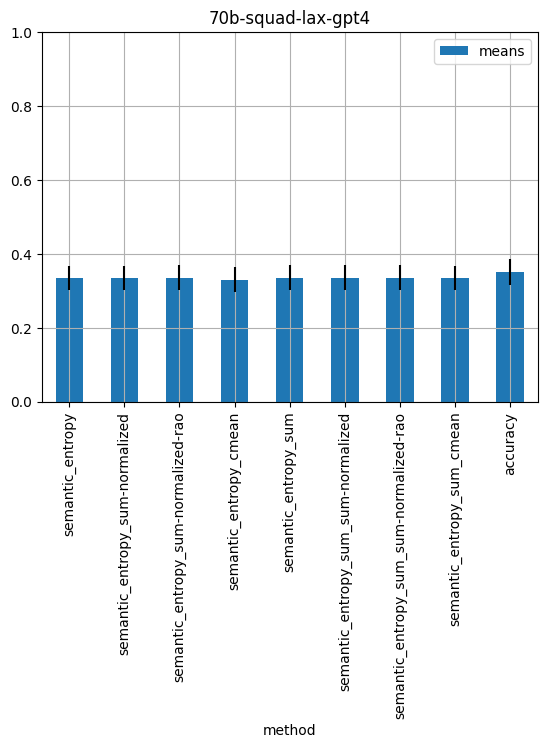

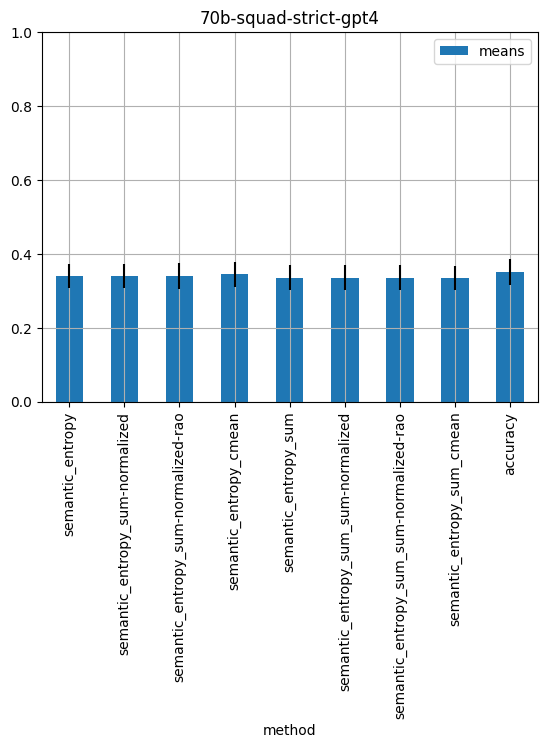

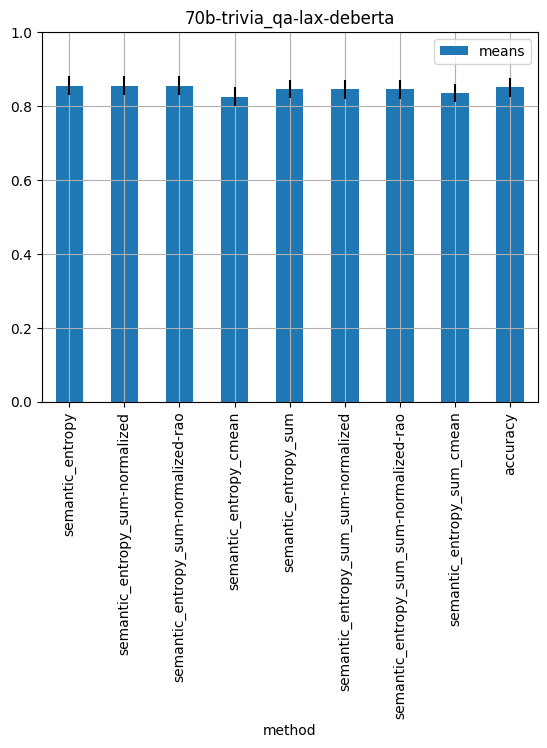

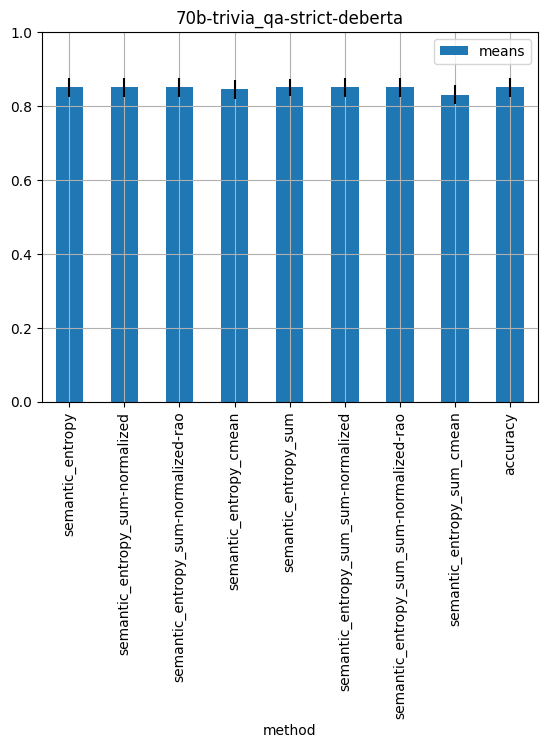

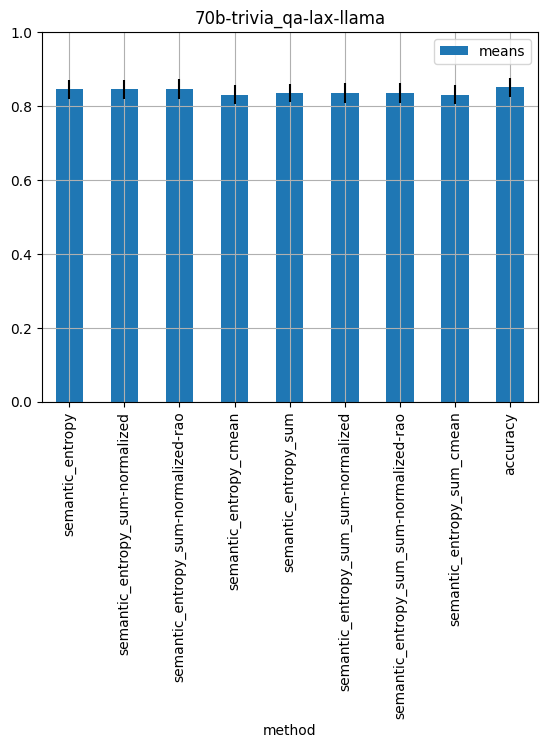

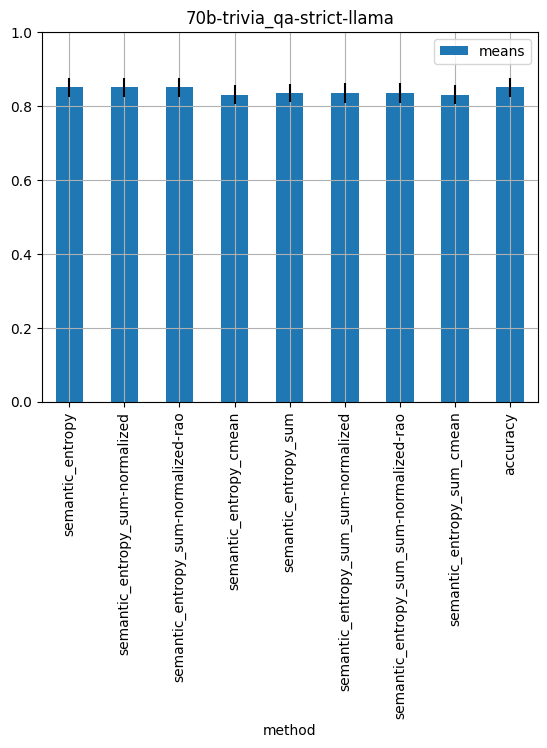

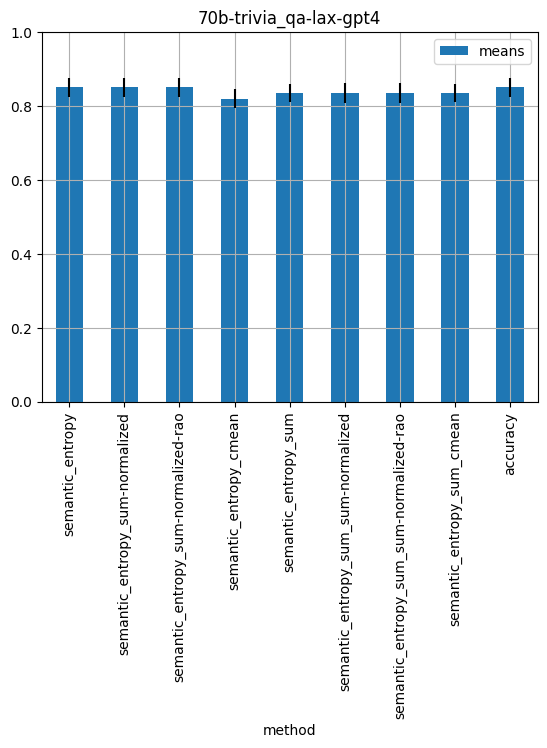

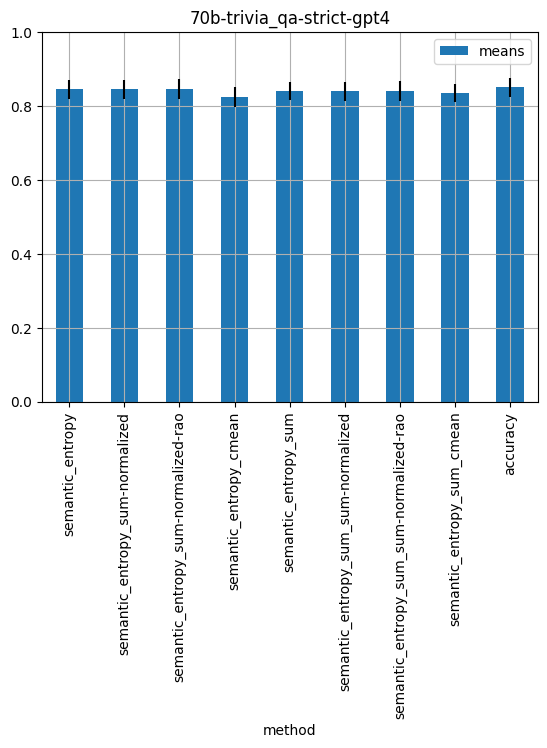

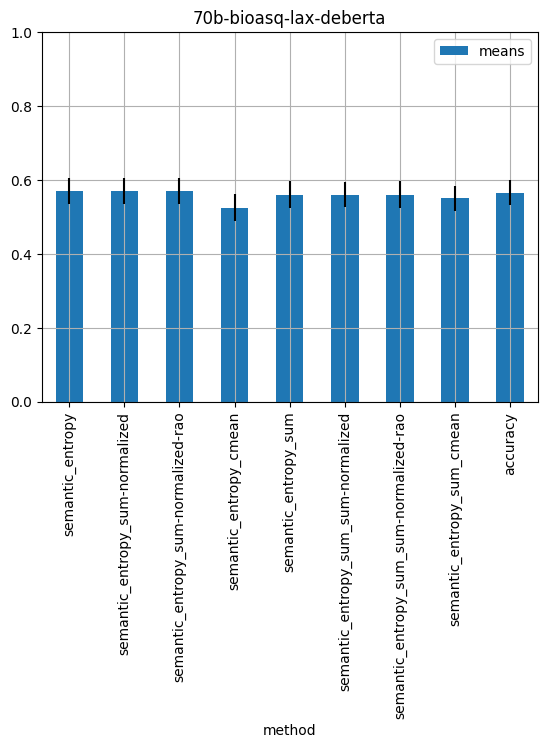

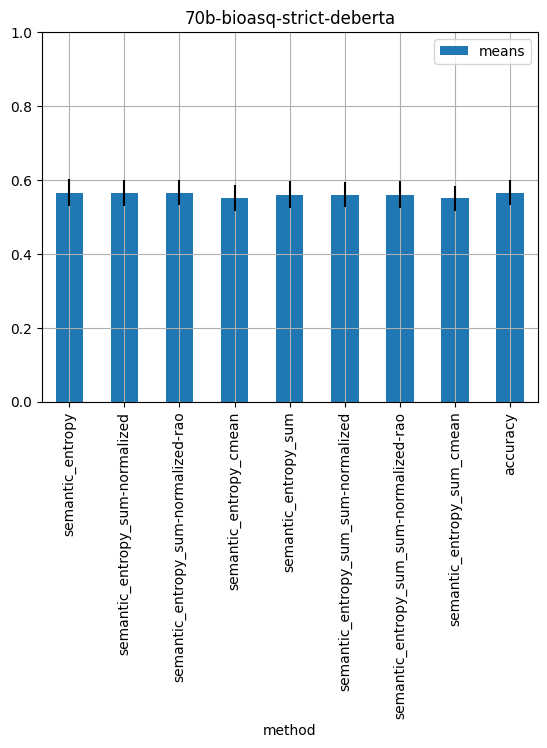

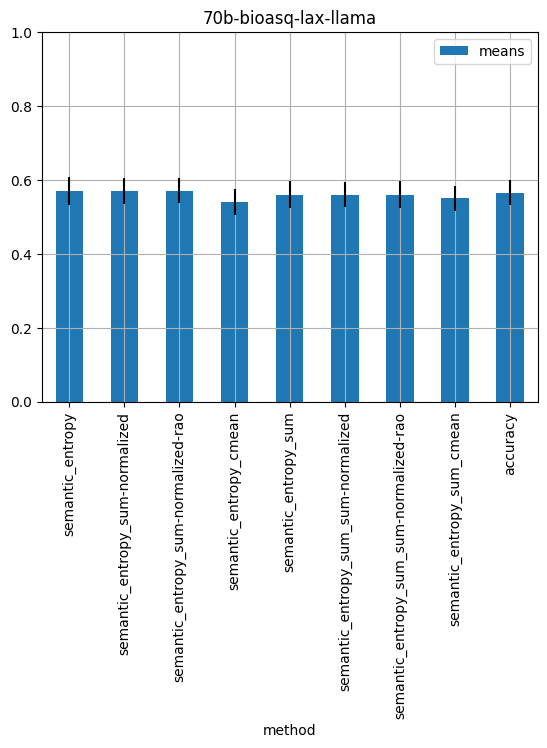

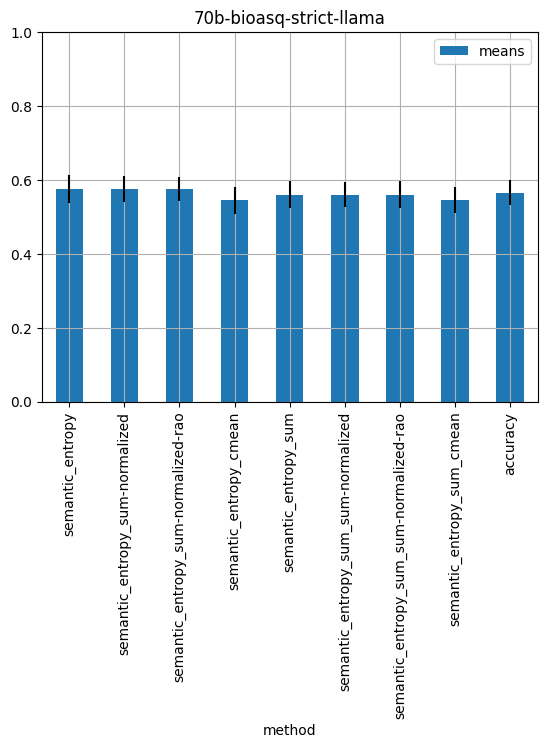

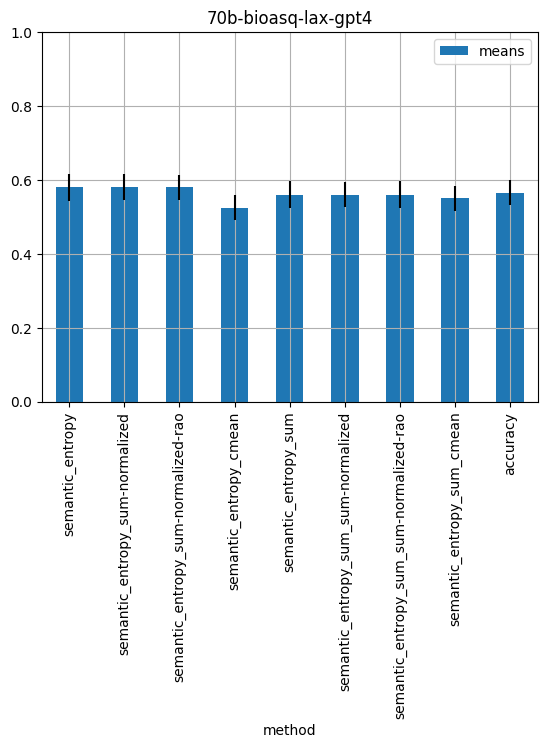

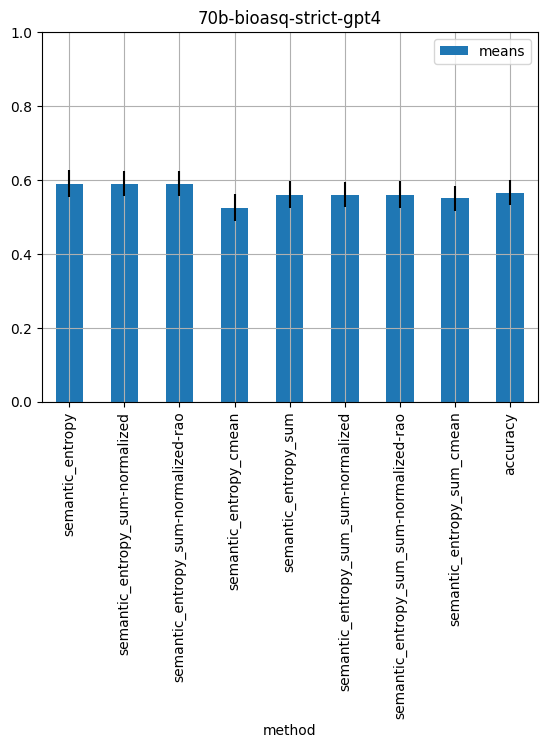

In [6]:
for wandb_id, run_name in runs.items():
    config = all_configs[wandb_id]
    results = all_results[wandb_id]

    df = get_perfs(results)
    plot_bar(df)
    plt.gca().set_title(run_name)
    plt.gca().grid()
    plt.gca().set_ylim(0, 1)


In [7]:
perfdf = {}
for wandb_id, run_name in runs.items():
    results = all_results[wandb_id]    
    perfdf[wandb_id] = get_perfs(results)

runids = list(perfdf.keys())
tmp = pd.DataFrame(perfdf[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(perfdf[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

perfdf = tmp.reset_index()

Text(0, 0.5, 'accuracy')

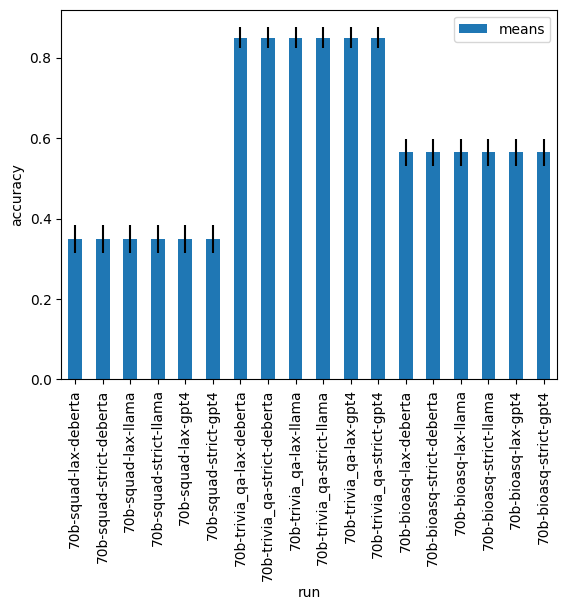

In [8]:
plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run'))
plt.gca().set_ylabel('accuracy')

In [9]:
tmp = perfdf.set_index('method').loc['accuracy']
tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:2]))
tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[2:]))
tmp.pivot(columns='model', index='dataset', values='means')

model,70b-bioasq,70b-squad,70b-trivia_qa
dataset,,,
lax-deberta,0.565,0.35,0.85
lax-gpt4,0.565,0.35,0.85
lax-llama,0.565,0.35,0.85
strict-deberta,0.565,0.35,0.85
strict-gpt4,0.565,0.35,0.85
strict-llama,0.565,0.35,0.85


* 7b largely performs very similar to 70b, usually a little worse (5-10%)
* Only big difference is for trivia-qa, where removing context leads to ~20 percent accuracy hit from ~85 to ~65 (this is not necessarily bad for us though)


In [24]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

pdfs = {}
for wandb_id in runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

In [25]:
# fig, axes_2d = plt.subplots(len(metric_names), len(runs), sharex=True, figsize=(15, 15), dpi=100)
# # fig.suptitle(config['dataset']['value'] + ' '+ plt.gca().get_title())
# for k, (name, axes) in enumerate(zip(list(metric_names), axes_2d)):

#     for i, (ax, wandb_id) in enumerate(zip(axes, runs)):
#         plot_bar_uncertainty(pdfs[wandb_id], name, ax=ax)

#         if i == 0:
#             ax.set_ylabel(name, fontsize=8, rotation=0, ha='right')

#         if k == 0:
#             ax.set_title(runs[wandb_id])


# plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [26]:
runids = list(pdfs.keys())

tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

all_runs = tmp.reset_index()

/tmp/ipykernel_967377/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_967377/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


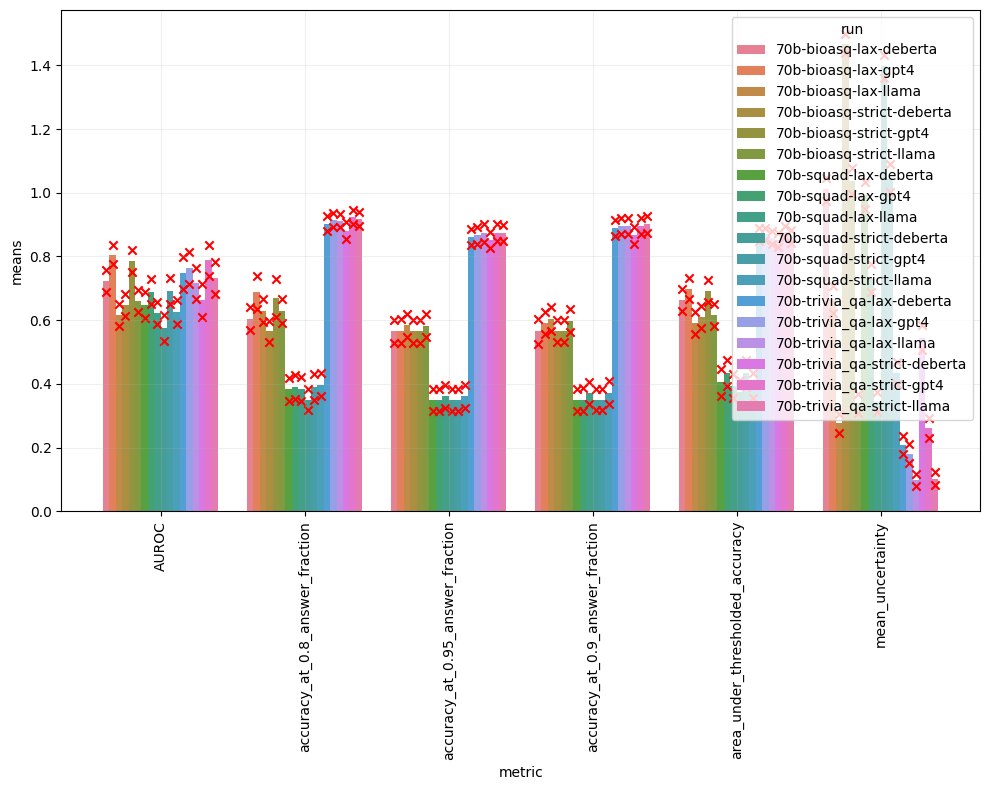

In [27]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'cluster_assignment_entropy']
df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_967377/1448009336.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[all_runs.metric != 'mean_uncertainty']
/tmp/ipykernel_967377/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_967377/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


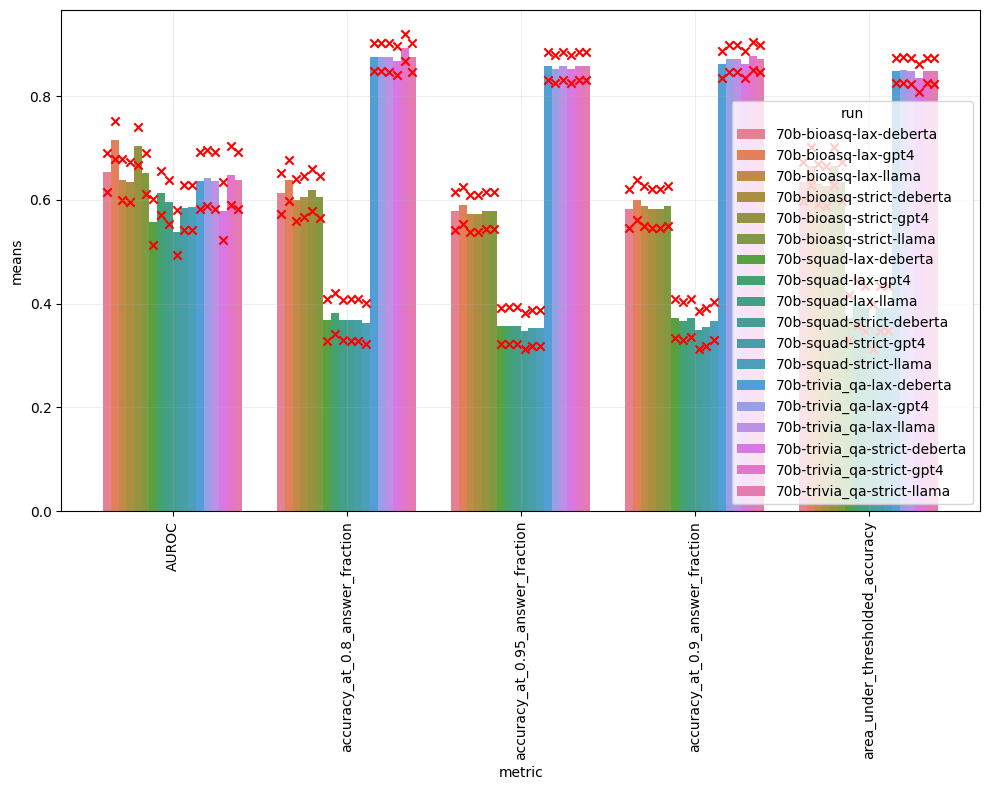

In [14]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'semantic_entropy_sum_cmean']
df2 = df2[all_runs.metric != 'mean_uncertainty']

df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_967377/3826733038.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_967377/3826733038.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


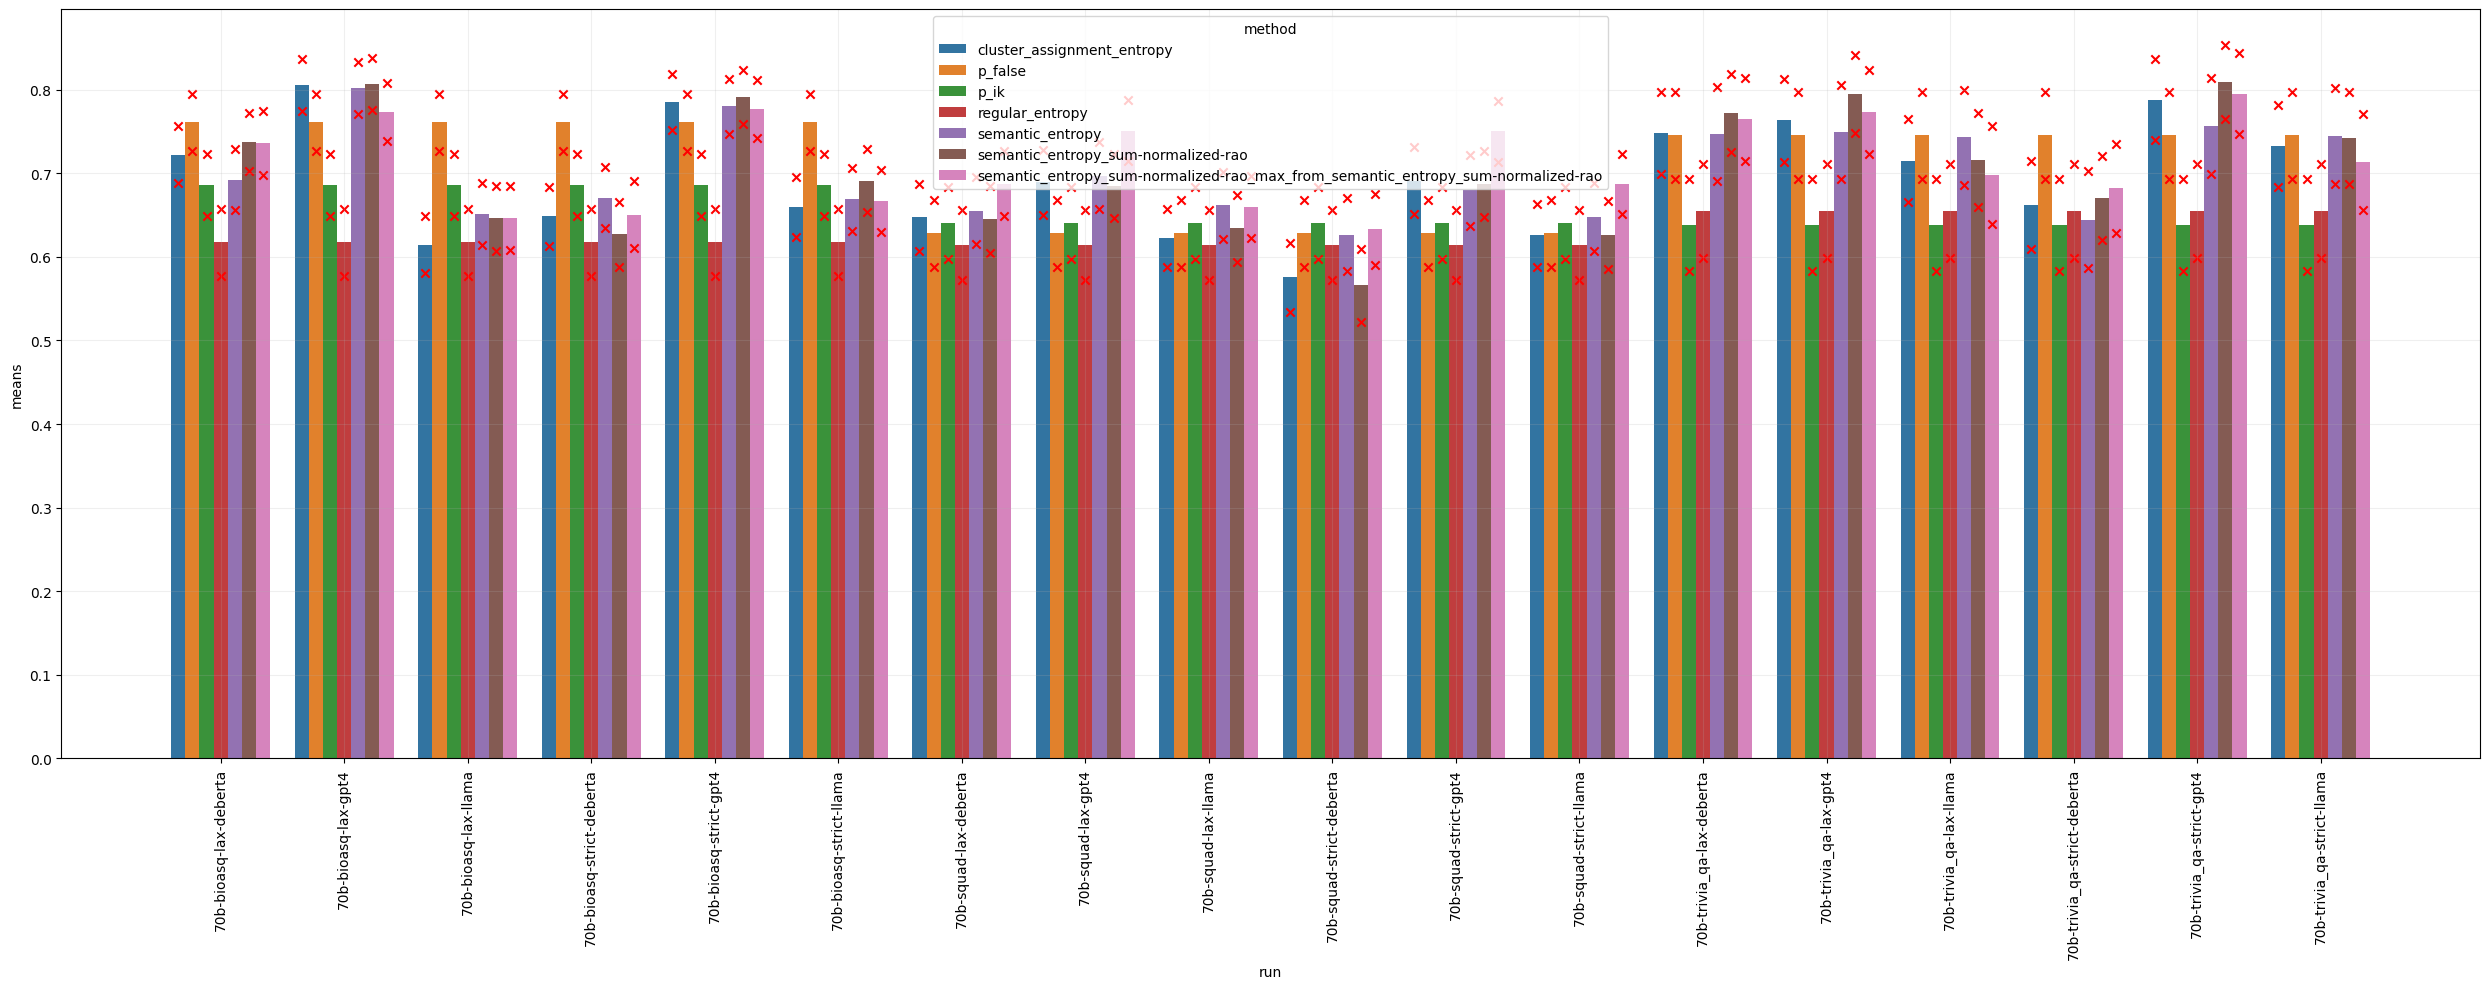

In [42]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2[df2.run.map(lambda x: '70b' in x)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(25, 10), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

* bioasq
    * lax deberta is better than (strict deberta, lax/strict llama)
    * interestingly: strict is better than lax for llama but not for deberta
* squad
    * lax deberta is better than (strict deberta, lax/strict llama)
    * gpt-4: strict performs almost the same as lax. lax being a tiny bit better for some variants!
    * again: strict llama better than lax llama
* trivia-qa:
    * lax deberta better than strict deberta
    * llama competitive with lax deberta but not better!
    * again strict better than lax
 
Conclusions:

* deberat lax is pretty good
* gpt-4 is better on squad --> check other datasets too

**Strict entailment with deberta seems clearly worse for long generations? but what about with llama? --> need other experiments to come in!**

In [43]:
all_runs['strictness'] = all_runs.run.map(lambda x: x.split('-')[-2])
all_runs['entailment'] = all_runs.run.map(lambda x: x.split('-')[-1])
all_runs['dataset'] = all_runs.run.map(lambda x: x.split('-')[1])

In [44]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]

In [45]:
semantic_methods = ['cluster_assignment_entropy', 'semantic_entropy', 'semantic_entropy_sum-normalized-rao', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

In [46]:
(tmp.set_index('method').loc[main_methods].reset_index().pivot(columns=['dataset', 'entailment', 'strictness'], index='method', values='means') * 100).style.background_gradient(sns.color_palette('crest', as_cmap=True), axis=None).format(precision=1)

In [21]:
# for each run (and for each model) I would like to see the best methods

In [22]:
# semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao --> this was the best method for short generations as well!

In [37]:
tmp.set_index('method').loc[semantic_methods].groupby(['strictness', 'entailment']).mean('means')[['means']]

means
strictness entailment          
lax        deberta     0.712965
           gpt4        0.757568
           llama       0.667359
strict     deberta     0.638117
           gpt4        0.757697
           llama       0.683764

Ignore gpt-4 strict, b/c not over the same set of datasets.

In [38]:
from IPython.display import display

In [39]:
# for each semantic method, I would like to build an auroc table [strictness/entailment]
for semantic_method in semantic_methods:
    print(semantic_method)
    tmp2 = tmp.set_index('method').loc[semantic_method].groupby(['strictness', 'entailment']).mean('means')[['means']]
    display(tmp2)
    best = tmp2.reset_index()[tmp2.reset_index().entailment != 'gpt4'].set_index(['strictness', 'entailment']).idxmax().values
    print('max exlcuding gpt-4', best)

cluster_assignment_entropy


means
strictness entailment          
lax        deberta     0.705908
           gpt4        0.752884
           llama       0.650858
strict     deberta     0.628783
           gpt4        0.755096
           llama       0.672653

max exlcuding gpt-4 [('lax', 'deberta')]
semantic_entropy


means
strictness entailment          
lax        deberta     0.698217
           gpt4        0.749406
           llama       0.685296
strict     deberta     0.647342
           gpt4        0.738802
           llama       0.687030

max exlcuding gpt-4 [('lax', 'deberta')]
semantic_entropy_sum-normalized-rao


means
strictness entailment          
lax        deberta     0.718033
           gpt4        0.762041
           llama       0.665319
strict     deberta     0.621156
           gpt4        0.762720
           llama       0.686455

max exlcuding gpt-4 [('lax', 'deberta')]
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao


means
strictness entailment          
lax        deberta     0.729703
           gpt4        0.765941
           llama       0.667964
strict     deberta     0.655188
           gpt4        0.774171
           llama       0.688919

max exlcuding gpt-4 [('lax', 'deberta')]


* **we now have full gpt-4 numbers**
    * let's go with gpt-4 strict! --> performs best for the variants that we care about!


In [50]:
tmp.set_index('entailment').loc['gpt4'].set_index('strictness').loc['strict'].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.774171,0.734496,0.813847
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.771195,0.732384,0.810007
semantic_entropy_sum-normalized-rao,0.762720,0.724082,0.801358
semantic_entropy_sum-normalized,0.757381,0.718993,0.795768
cluster_assignment_entropy,0.755096,0.714589,0.795602
semantic_entropy_max_from_semantic_entropy,0.752339,0.711150,0.793528
semantic_entropy,0.738802,0.694619,0.782984
p_false,0.711556,0.669339,0.753774
semantic_entropy_sum_max_from_semantic_entropy_sum,0.706286,0.662892,0.749680


In [51]:
tmp.set_index('entailment').loc['gpt4'].set_index('strictness').loc['lax'].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.765941,0.725516,0.806365
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.762276,0.722910,0.801642
semantic_entropy_sum-normalized-rao,0.762041,0.723015,0.801066
semantic_entropy_sum-normalized,0.756128,0.717132,0.795125
semantic_entropy_max_from_semantic_entropy,0.754768,0.713522,0.796013
cluster_assignment_entropy,0.752884,0.713092,0.792676
semantic_entropy,0.749406,0.706969,0.791842
semantic_entropy_sum_max_from_semantic_entropy_sum,0.726315,0.685233,0.767396
semantic_entropy_sum_sum-normalized-rao_max_from_semantic_entropy_sum_sum-normalized-rao,0.726072,0.681065,0.771079


/tmp/ipykernel_522220/3304450561.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_522220/3304450561.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


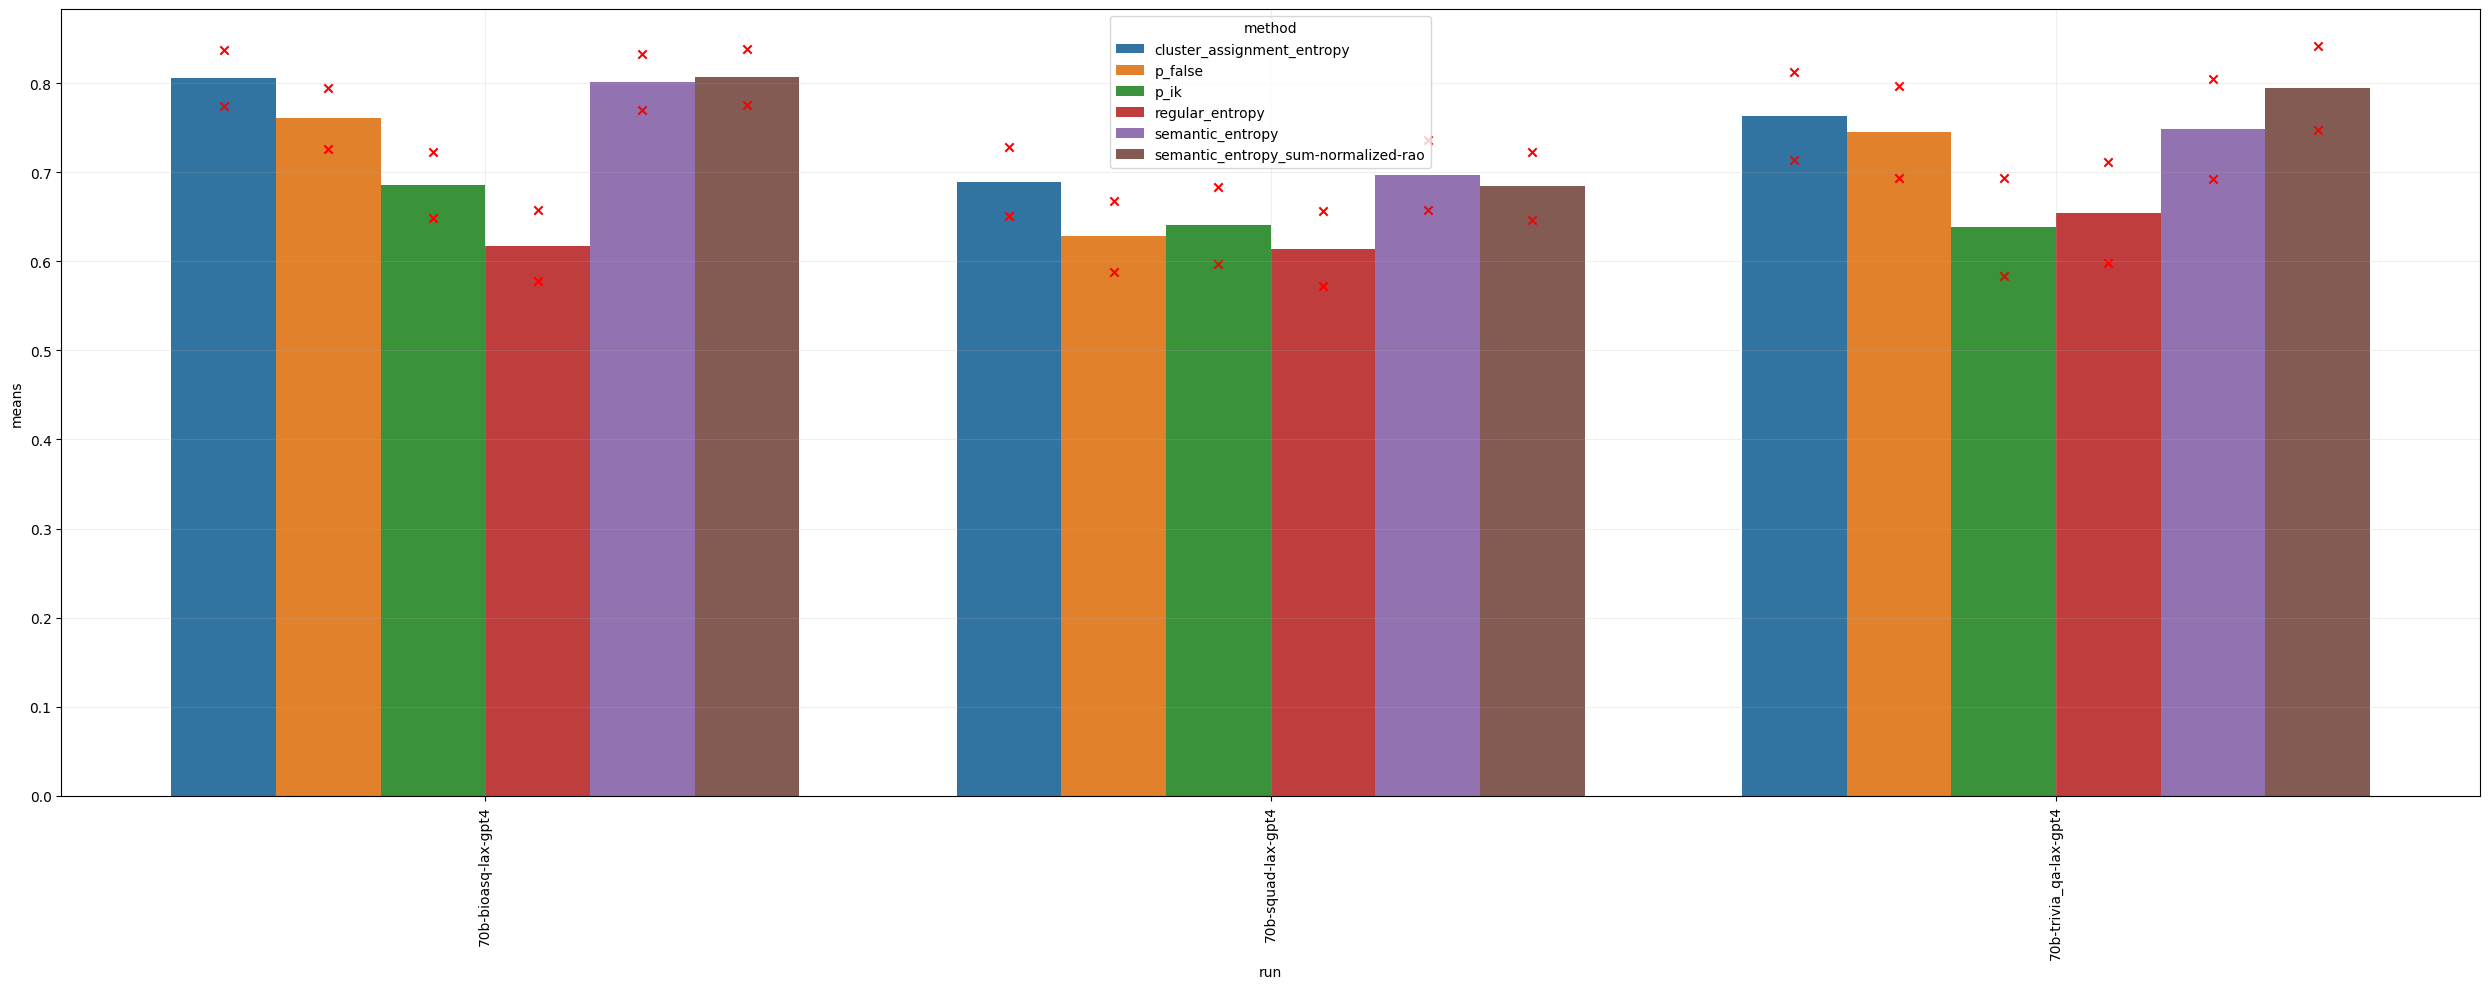

In [131]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']



df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2[df2.run.map(lambda x: '70b' in x)]
df2 = df2[df2.run.map(lambda x: 'gpt4' in x and 'lax' in x)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(25, 10), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

In [143]:

[1,2,3].index(1)

0

/tmp/ipykernel_522220/2719254657.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_522220/2719254657.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


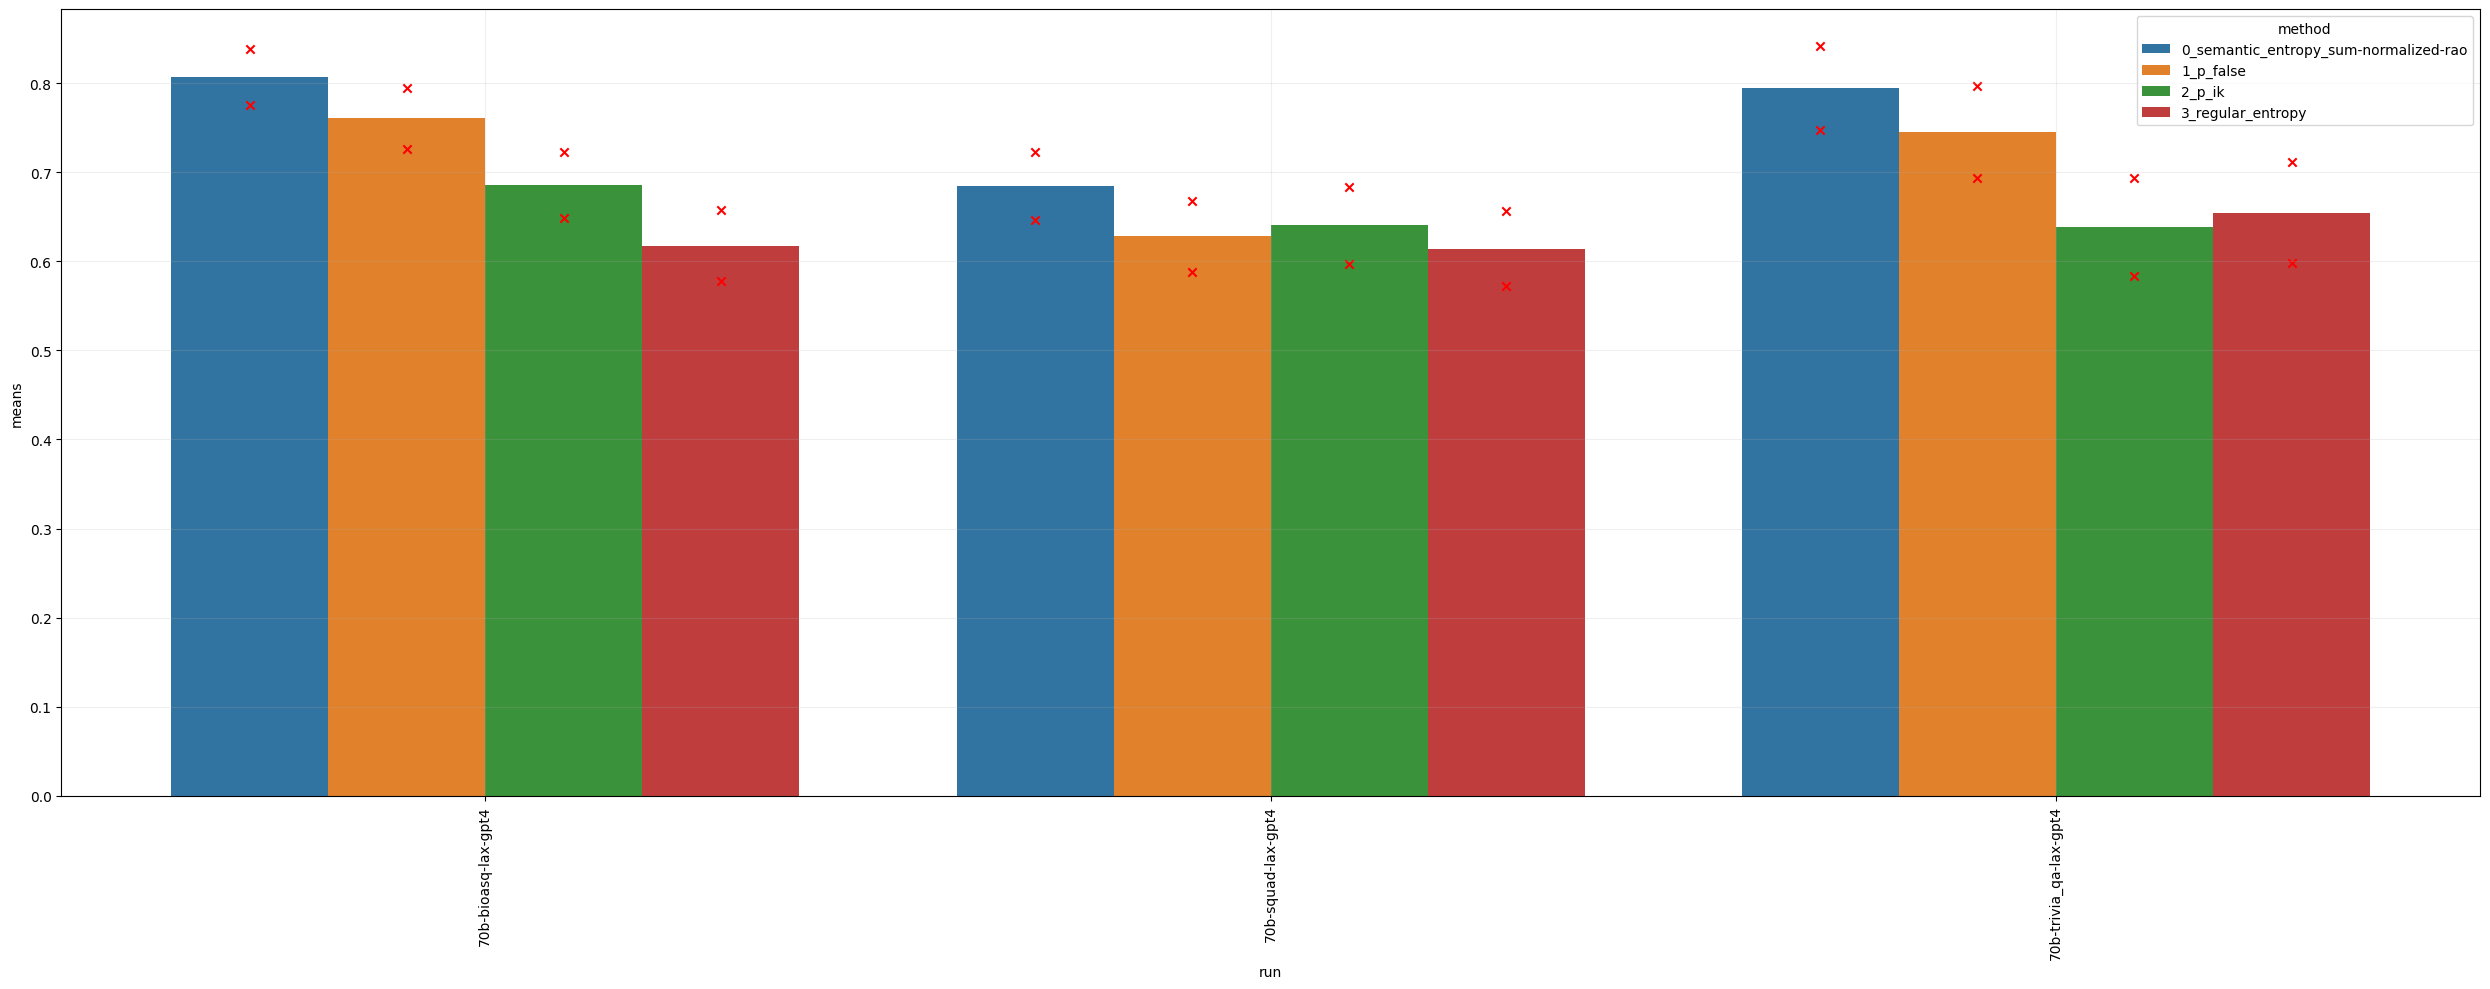

In [146]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']
main_methods = ['semantic_entropy_sum-normalized-rao', 'p_false', 'p_ik', 'regular_entropy',]


df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2['method'] = df2.method.map(lambda x: f'{main_methods.index(x)}_{x}')
df2 = df2[df2.run.map(lambda x: '70b' in x)]
df2 = df2[df2.run.map(lambda x: 'gpt4' in x and 'lax' in x)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(25, 10), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

In [20]:
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.691722,0.650443,0.733001
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.690087,0.649079,0.731096
semantic_entropy_max_from_semantic_entropy,0.686839,0.645797,0.727881
semantic_entropy_sum-normalized-rao,0.671936,0.631304,0.712569
cluster_assignment_entropy,0.668696,0.627542,0.709850
semantic_entropy_sum-normalized,0.668510,0.627020,0.710001
p_false,0.667889,0.625738,0.710040
semantic_entropy,0.663491,0.620564,0.706418
semantic_entropy_sum_sum-normalized-rao_max_from_semantic_entropy_sum_sum-normalized-rao,0.657768,0.615415,0.700121


In [21]:
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized	

NameError: name 'semantic_entropy_sum' is not defined

In [ ]:
tmp[tmp.run.map(lambda x: '70b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

In [ ]:
tmp[tmp.run.map(lambda x: '7b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

In [ ]:
tmp.set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

In [ ]:
tmp[tmp.run.map(lambda x: '7b' in x)].set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)